In [1]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
os.chdir(r"C:\Users\ElMorado\OneDrive\Escritorio\LIBROS Y CURSOS\CURSO EBAC\Datasets")
df = pd.read_csv('wine-clustering.csv')
df

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [52]:
from sklearn.neighbors import KNeighborsRegressor

# Asignamos los valores a las variables
X = df.drop(columns="Alcohol") 
y = df["Alcohol"]


In [55]:
from sklearn.preprocessing import StandardScaler

# Normalizacion de| los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [57]:
# Crear el modelo con 5 vecinos
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_scaled, y)

# Características del vino a analizar (sin la variable objetivo)
query = np.array([[2, 2.5, 16, 115, 3, 2.5, 0.4, 2, 9, 1, 3.5, 800]])

# Escalar el query con el mismo transformador
query_scaled = scaler.transform(query)
# obtenemos las coordenadas del query

# Obtener los índices de los 5 vecinos más cercanos
_, indices = knn.kneighbors(query_scaled)
# aqui obtenemos los indices de los 5 vecinos, 
# en base al query; es decir los vecinos del punto seleccionado 


# knn.kneighbors() devuelve dos valores: (distances, indices)
# Como solo queremos los indices, usamos _ para ignorar distances.



C:\Users\ElMorado\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [59]:
# Obtener las concentraciones de alcohol de los 5 vecinos y las guardamos en:
alcohol_neighbors = y.iloc[indices[0]].values

# Imprimir cada valor de cada vecino
print("Concentraciones de alcohol de los 5 vecinos más cercanos:")
for i, value in enumerate(alcohol_neighbors, 1):
    print(f"Vecino {i}: {value}")

# Calcular promedio
# al finalizar el loop se calcula la media de la lista generada
average_alcohol = alcohol_neighbors.mean()
print(f"\nPromedio de alcohol: {average_alcohol:.2f}")


Concentraciones de alcohol de los 5 vecinos más cercanos:
Vecino 1: 13.56
Vecino 2: 14.22
Vecino 3: 13.94
Vecino 4: 14.23
Vecino 5: 14.06

Promedio de alcohol: 14.00


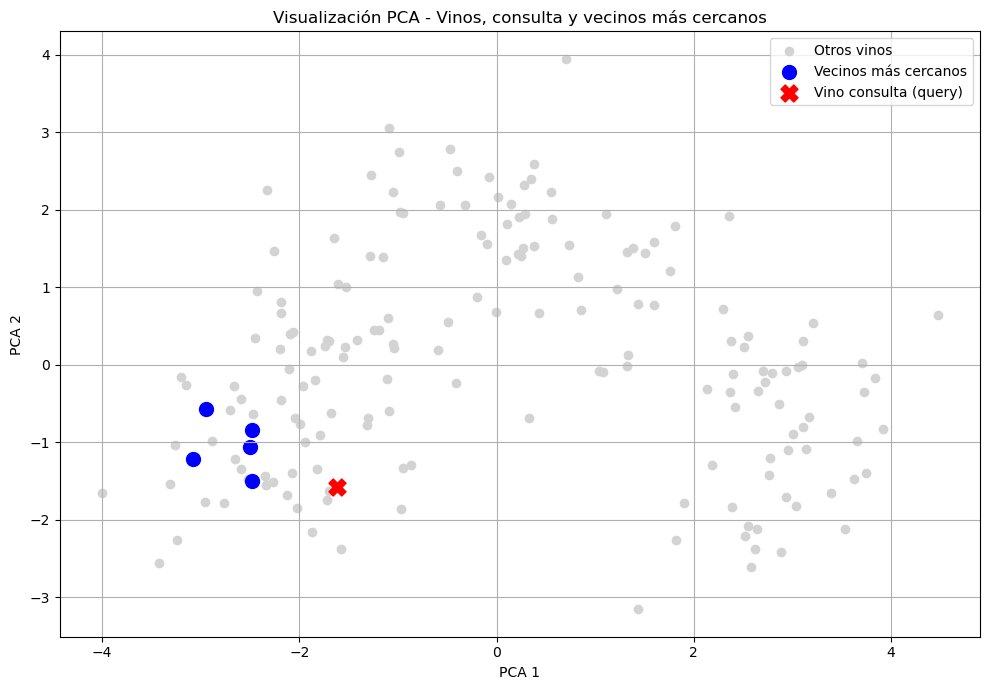

In [63]:
from sklearn.decomposition import PCA

# Aplicar PCA para reducir los datos a 2 dimensiones
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
query_pca = pca.transform(query_scaled)
neighbors_pca = X_pca[indices[0]]

# Crear un gráfico de dispersión
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='lightgray', label='Otros vinos')

# Graficar los vecinos más cercanos
plt.scatter(neighbors_pca[:, 0], neighbors_pca[:, 1], c='blue', 
            label='Vecinos más cercanos', s=100)

# Graficar la query
plt.scatter(query_pca[0, 0], query_pca[0, 1], c='red', 
            label='Vino consulta (query)', s=150, marker='X')

plt.title('Visualización PCA - Vinos, consulta y vecinos más cercanos')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.grid(True)
plt.tight_layout() # comando para ajustar automaticamente todos los detalles del grafico
plt.show()


# Segundo Problema

In [3]:
# se realiza el array con el que se trabajara
transactions = [
    ['bread', 'butter', 'wine', 'bananas', 'coffee', 'carrots'],
    ['bread', 'butter', 'wine'],
    ['milk', 'bread', 'carrots'],
    ['milk', 'bananas'],
    ['wine', 'bread', 'coffee'],
    ['butter', 'carrots'],
    ['milk', 'coffee'],
    ['bread', 'wine'],
    ['butter', 'carrots', 'wine'],
    ['milk', 'bananas', 'bread'],
    ['coffee', 'bananas', 'butter']
]


In [27]:
# se importan las librerias necesarias para el analisi
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import pandas as pd
import matplotlib.pyplot as plt


In [29]:
# Codificar las transacciones para poder saber
# en que filas se repiten los articulos
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_ary, columns=te.columns_)
df 


,bananas,bread,butter,carrots,coffee,milk,wine
0,True,True,True,True,True,False,True
1,False,True,True,False,False,False,True
2,False,True,False,True,False,True,False
3,True,False,False,False,False,True,False
4,False,True,False,False,True,False,True
5,False,False,True,True,False,False,False
6,False,False,False,False,True,True,False
7,False,True,False,False,False,False,True
8,False,False,True,True,False,False,True
9,True,True,False,False,False,True,False


In [31]:
# Aplicar algoritmo Apriori
# para saber el nivel de soporte de los articulos
frequent_itemsets = apriori(df, min_support=0.2, use_colnames=True)
frequent_itemsets



,support,itemsets
0,0.363636,(bananas)
1,0.545455,(bread)
2,0.454545,(butter)
3,0.363636,(carrots)
4,0.363636,(coffee)
5,0.363636,(milk)
6,0.454545,(wine)
7,0.363636,"(wine, bread)"
8,0.272727,"(carrots, butter)"
9,0.272727,"(wine, butter)"


In [44]:
# Generar reglas de asociación y observamos los niveles de lift y confianza
rules = association_rules(frequent_itemsets, metric="lift", 
                          min_threshold=1.0).sort_values('confidence', 
                                                         ascending = False).reset_index(drop=True)
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

  antecedents consequents   support  confidence      lift
0      (wine)     (bread)  0.363636    0.800000  1.466667
1   (carrots)    (butter)  0.272727    0.750000  1.650000
2     (bread)      (wine)  0.363636    0.666667  1.466667
3    (butter)   (carrots)  0.272727    0.600000  1.650000
4      (wine)    (butter)  0.272727    0.600000  1.320000
5    (butter)      (wine)  0.272727    0.600000  1.320000
